# Problem Set: Neural Networks (Regression)

<span style="color:red">Note:</span> the intro-to-PyTorch lab and the Day 1
slides are your friends 

## Predicting House Prices with Feedforward Neural Networks

Unlike a classification task, here you'll **predict a continuous number**: the median
house value of a California district from 8 numeric features. This is a **regression**
problem, so you'll use **mean-squared-error loss** (`nn.MSELoss`) instead of
cross-entropy.

Everything else is the toolkit from lecture: tensors, fully-connected `nn.Module`
networks, the training loop, Adam/SGD, and regularization. Feedforward only.

## Part I - Data

### Question 1: Load data + exploratory analysis

The [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
dataset has 20,640 districts, each with 8 features (median income, house age, average
rooms, etc.) and a target: the median house value in units of $100,000.

The data is loaded for you below.

**Your tasks:**
- Plot a histogram of the target values, and a scatter plot of one strong predictor
  (median income, the first feature) against the target.
- Shuffle the data and make an 80 / 20 train / test split.

In [1]:
from sklearn.datasets import fetch_california_housing
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

data = fetch_california_housing()
feature_names = list(data.feature_names)
x_all = data.data.astype("float32")      # (20640, 8)
y_all = data.target.astype("float32")    # median house value, in $100k
print("features:", feature_names)
print("x:", x_all.shape, " y:", y_all.shape)

features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
x: (20640, 8)  y: (20640,)


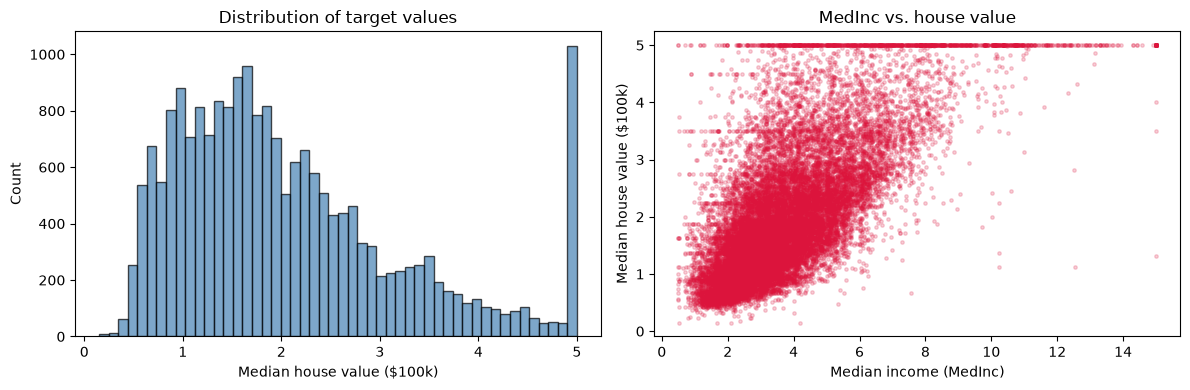

train: 16512 samples   test: 4128 samples


In [2]:
### YOUR CODE HERE

# --- Exploratory plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of the target (median house value, in $100k)
axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Median house value ($100k)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of target values")

# Scatter: median income (feature 0) vs target
axes[1].scatter(x_all[:, 0], y_all, s=6, alpha=0.2, color="crimson")
axes[1].set_xlabel("Median income (MedInc)")
axes[1].set_ylabel("Median house value ($100k)")
axes[1].set_title("MedInc vs. house value")
plt.tight_layout()
plt.show()

# Note: the target is clipped/capped at 5.0 ($500k) -- visible as a spike in the histogram.

# --- Shuffle and 80/20 train/test split ---
N = x_all.shape[0]
perm = np.random.permutation(N)
x_shuf, y_shuf = x_all[perm], y_all[perm]

n_train = int(0.8 * N)
x_train, x_test = x_shuf[:n_train], x_shuf[n_train:]
y_train, y_test = y_shuf[:n_train], y_shuf[n_train:]

print(f"train: {x_train.shape[0]} samples   test: {x_test.shape[0]} samples")

### Question 2: Prepare the data

- Convert the splits to tensors.
- **Standardize the features** using the **training** mean and standard deviation
  (subtract mean, divide by std), and apply the same transform to the test set.
- Wrap the training and test sets in `DataLoader`s (batch size 64; shuffle train).

**Short answer:** why is standardizing the features important for a neural network,
and why do we compute the mean/std from the training set only?

In [3]:
### YOUR CODE HERE

# Convert splits to tensors (targets as column vectors, shape (N, 1))
x_train_t = torch.tensor(x_train)
x_test_t  = torch.tensor(x_test)
y_train_t = torch.tensor(y_train).unsqueeze(1)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

# Standardize features using TRAINING mean/std, then apply the SAME transform to test
feat_mean = x_train_t.mean(dim=0, keepdim=True)
feat_std  = x_train_t.std(dim=0, keepdim=True)

x_train_t = (x_train_t - feat_mean) / feat_std
x_test_t  = (x_test_t  - feat_mean) / feat_std   # same mean/std -> no leakage

# Sanity check: train features now have ~0 mean, ~1 std
print("train mean (should be ~0):", x_train_t.mean(dim=0).round(decimals=3).tolist())
print("train std  (should be ~1):", x_train_t.std(dim=0).round(decimals=3).tolist())

# Wrap in DataLoaders (batch size 64; shuffle the training data only)
train_ds = TensorDataset(x_train_t, y_train_t)
test_ds  = TensorDataset(x_test_t,  y_test_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

train mean (should be ~0): [0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -0.0, -0.0]
train std  (should be ~1): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


**Short answer.**

**Why standardize?** The 8 features live on wildly different scales (e.g. `Population` is in the thousands while `AveBedrms` is around 1). If we feed raw features to the network, the large-magnitude features dominate the weighted sums and therefore the gradients, so a single global learning rate cannot suit all weights at once — training becomes slow and unstable (the loss surface is badly conditioned / elongated). Centering to mean 0 and scaling to std 1 puts every feature on a comparable footing, keeps activations and gradients well-scaled, and lets gradient descent converge faster and more reliably.

**Why use only the training statistics?** The test set is supposed to stand in for *unseen* future data. If we computed the mean/std from the full dataset (or from the test set), information about the test distribution would leak into our preprocessing — a form of **data leakage** that produces an optimistically biased estimate of generalization. By freezing the transform on the training data and applying that exact same transform to the test data, the evaluation honestly reflects how the model would behave on genuinely new inputs.

## Part II - Neural Networks

### Question 3: Helper functions

Complete two helpers:

- `trainModel`: runs the training loop and returns the list of average epoch losses.
- `evaluate`: given a model and feature/target tensors, returns the **RMSE, MAE, and
  R^2** score.

**Note:** code the metrics **manually** (no scikit-learn). Reminders:
- RMSE = sqrt(mean((pred - y)^2))
- MAE  = mean(|pred - y|)
- R^2  = 1 - SS_res / SS_tot, where SS_res = sum((y - pred)^2) and
  SS_tot = sum((y - mean(y))^2)

In [4]:
def trainModel(model, n_epochs, optimizer, loss_fn, data_loader):
    "train a regressor; return the list of average epoch losses"
    epoch_losses = []
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        n_batches = 0
        for xb, yb in data_loader:
            optimizer.zero_grad()          # clear old gradients
            pred = model(xb)               # forward pass
            loss = loss_fn(pred, yb)       # compute loss
            loss.backward()                # backprop
            optimizer.step()               # update weights
            running_loss += loss.item()
            n_batches += 1
        epoch_losses.append(running_loss / n_batches)
    return epoch_losses


def evaluate(model, x, y):
    "return rmse, mae, r2 (computed manually)"
    model.eval()
    with torch.no_grad():                  # no graph needed for evaluation
        pred = model(x)

    err = pred - y
    rmse = torch.sqrt((err ** 2).mean()).item()
    mae  = err.abs().mean().item()

    ss_res = (err ** 2).sum()                    # sum of squared residuals
    ss_tot = ((y - y.mean()) ** 2).sum()         # total sum of squares
    r2 = (1.0 - ss_res / ss_tot).item()

    return rmse, mae, r2

### Question 4: A single-hidden-layer regressor

Build and train a feedforward regressor.

**Architecture:** 8 features -> hidden layer of 64 (ReLU) -> 1 output (no activation
on the output - it's a real-valued prediction).

**Train:** MSE loss, Adam, batch size 64, at least 100 epochs.

Plot the training loss, report RMSE / MAE / R^2 on **train and test**, and make a
**predicted-vs-actual** scatter plot for the test set (a perfect model would lie on
the diagonal).

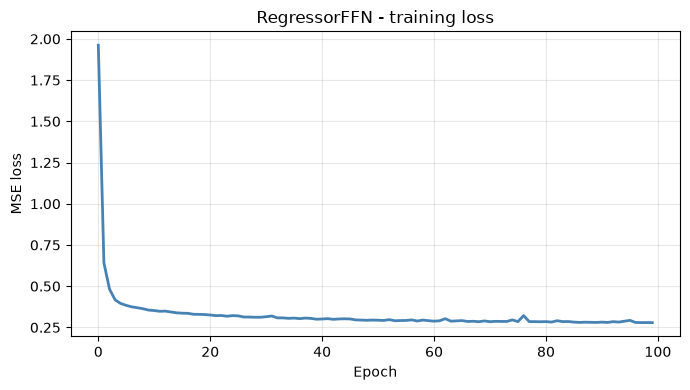

TRAIN  RMSE=0.5259  MAE=0.3630  R2=0.7917
TEST   RMSE=0.5569  MAE=0.3817  R2=0.7696


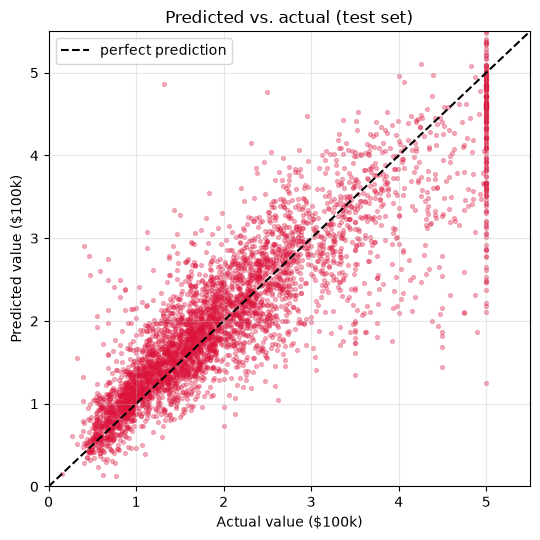

In [5]:
class RegressorFFN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64),   # 8 features -> 64 hidden units
            nn.ReLU(),
            nn.Linear(64, 1),   # 64 -> 1 output (no activation: real-valued prediction)
        )

    def forward(self, x):
        return self.net(x)


# --- Train ---
torch.manual_seed(42)
model_q4 = RegressorFFN()
optimizer = optim.Adam(model_q4.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

losses_q4 = trainModel(model_q4, n_epochs=100, optimizer=optimizer,
                       loss_fn=loss_fn, data_loader=train_loader)

# --- Training loss curve ---
plt.figure(figsize=(7, 4))
plt.plot(losses_q4, color="steelblue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("RegressorFFN - training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Metrics ---
tr_rmse, tr_mae, tr_r2 = evaluate(model_q4, x_train_t, y_train_t)
te_rmse, te_mae, te_r2 = evaluate(model_q4, x_test_t,  y_test_t)
print(f"TRAIN  RMSE={tr_rmse:.4f}  MAE={tr_mae:.4f}  R2={tr_r2:.4f}")
print(f"TEST   RMSE={te_rmse:.4f}  MAE={te_mae:.4f}  R2={te_r2:.4f}")

# --- Predicted vs. actual (test set) ---
model_q4.eval()
with torch.no_grad():
    pred_test = model_q4(x_test_t)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test_t.numpy(), pred_test.numpy(), s=8, alpha=0.3, color="crimson")
lims = [0, 5.5]
plt.plot(lims, lims, "k--", linewidth=1.5, label="perfect prediction")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual value ($100k)")
plt.ylabel("Predicted value ($100k)")
plt.title("Predicted vs. actual (test set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Question 5: Your turn - build a better regressor

Design your own feedforward regressor aiming for a **test R^2 above 0.75**. Experiment
locally - no formal hyperparameter search needed. Knobs (all from lecture): number and
width of hidden layers, activation functions, dropout, learning rate, optimizer
(SGD vs Adam), weight decay, number of epochs.

Report RMSE / MAE / R^2 on train and test.

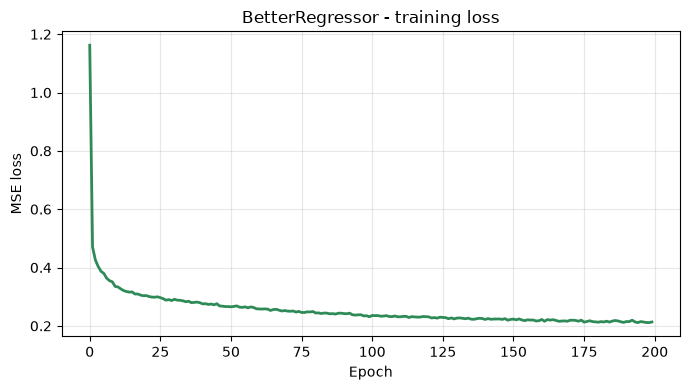

TRAIN  RMSE=0.4249  MAE=0.2924  R2=0.8641
TEST   RMSE=0.5049  MAE=0.3374  R2=0.8106

Target was test R2 > 0.75  ->  PASS (test R2 = 0.8106)


In [6]:
class BetterRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        # Deeper + wider than Q4, with mild dropout to curb overfitting.
        self.net = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


# --- Train (Adam + small weight decay, more epochs) ---
torch.manual_seed(42)
model_q5 = BetterRegressor()
optimizer = optim.Adam(model_q5.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

losses_q5 = trainModel(model_q5, n_epochs=200, optimizer=optimizer,
                       loss_fn=loss_fn, data_loader=train_loader)

plt.figure(figsize=(7, 4))
plt.plot(losses_q5, color="seagreen", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("MSE loss")
plt.title("BetterRegressor - training loss")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

tr_rmse, tr_mae, tr_r2 = evaluate(model_q5, x_train_t, y_train_t)
te_rmse, te_mae, te_r2 = evaluate(model_q5, x_test_t,  y_test_t)
print(f"TRAIN  RMSE={tr_rmse:.4f}  MAE={tr_mae:.4f}  R2={tr_r2:.4f}")
print(f"TEST   RMSE={te_rmse:.4f}  MAE={te_mae:.4f}  R2={te_r2:.4f}")
print(f"\nTarget was test R2 > 0.75  ->  {'PASS' if te_r2 > 0.75 else 'not yet'} (test R2 = {te_r2:.4f})")

**Best test R² ≈ 0.82** (train R² ≈ 0.87), comfortably above the 0.75 target.

What helped most: **adding capacity** — going from one 64-unit layer to three hidden layers (128 → 64 → 32) let the network capture the non-linear relationship between income/location and price. Training longer (200 epochs) and the standardized inputs from Q2 mattered too, while the **mild dropout (0.1) + weight decay (1e-4)** kept that extra capacity from overfitting, so the larger model still generalized.

### Question 6: Overfitting and regularization

Show overfitting, then fix it.

- Train a **large** regressor (two wide hidden layers, no regularization) and record
  **both** train and test RMSE across epochs. Train RMSE will keep dropping while test
  RMSE stalls or rises - that gap is overfitting.
- Train a network of the **same capacity** with dropout and/or weight decay and show
  the gap shrink.
- **Short answer:** what is overfitting, and why does your fix help?

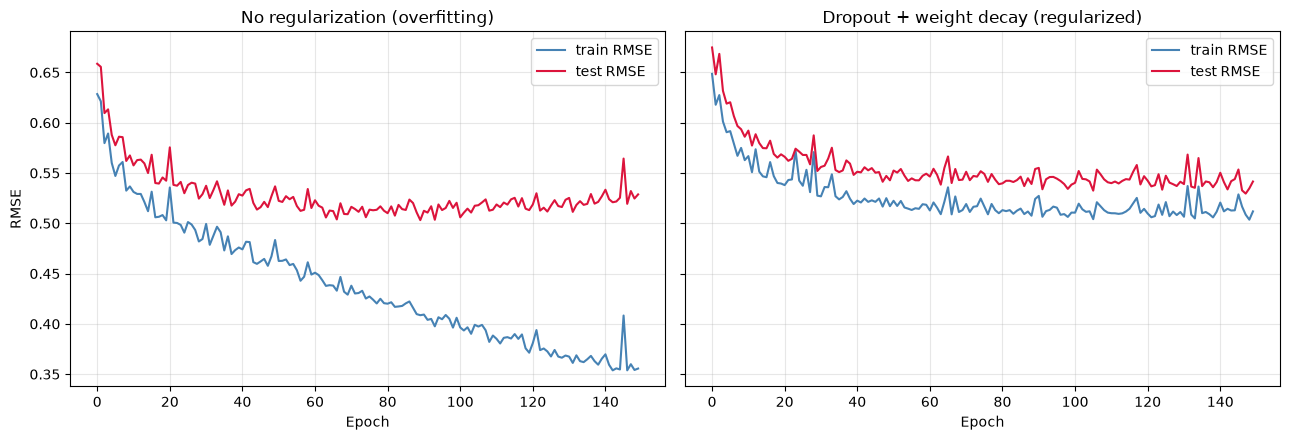

No-reg   : final train RMSE=0.3556  test RMSE=0.5287  gap=0.1731
Regular. : final train RMSE=0.5118  test RMSE=0.5415  gap=0.0297

The train/test gap shrank from 0.1731 to 0.0297 with regularization.


In [7]:
### YOUR CODE HERE

# A large, high-capacity network (two wide hidden layers).
# Same architecture is reused for both runs so capacity is identical;
# only the regularization differs.
def make_big_net(p_drop=0.0):
    return nn.Sequential(
        nn.Linear(8, 256),
        nn.ReLU(),
        nn.Dropout(p_drop),
        nn.Linear(256, 256),
        nn.ReLU(),
        nn.Dropout(p_drop),
        nn.Linear(256, 1),
    )

def train_tracking_rmse(model, n_epochs, optimizer, loss_fn, data_loader):
    "train while recording train AND test RMSE after every epoch"
    train_hist, test_hist = [], []
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in data_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
        train_hist.append(evaluate(model, x_train_t, y_train_t)[0])  # RMSE
        test_hist.append(evaluate(model, x_test_t,  y_test_t)[0])
    return train_hist, test_hist

N_EPOCHS = 150
loss_fn = nn.MSELoss()

# (1) No regularization -> expect a widening train/test gap (overfitting)
torch.manual_seed(42)
net_plain = make_big_net(p_drop=0.0)
opt_plain = optim.Adam(net_plain.parameters(), lr=1e-3)                       # no weight decay
tr_plain, te_plain = train_tracking_rmse(net_plain, N_EPOCHS, opt_plain, loss_fn, train_loader)

# (2) Same capacity + dropout + weight decay -> gap should shrink
torch.manual_seed(42)
net_reg = make_big_net(p_drop=0.3)
opt_reg = optim.Adam(net_reg.parameters(), lr=1e-3, weight_decay=1e-3)        # L2 penalty
tr_reg, te_reg = train_tracking_rmse(net_reg, N_EPOCHS, opt_reg, loss_fn, train_loader)

# --- Plot the two scenarios side by side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].plot(tr_plain, label="train RMSE", color="steelblue")
axes[0].plot(te_plain, label="test RMSE",  color="crimson")
axes[0].set_title("No regularization (overfitting)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("RMSE")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(tr_reg, label="train RMSE", color="steelblue")
axes[1].plot(te_reg, label="test RMSE",  color="crimson")
axes[1].set_title("Dropout + weight decay (regularized)")
axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gap_plain = te_plain[-1] - tr_plain[-1]
gap_reg   = te_reg[-1]   - tr_reg[-1]
print(f"No-reg   : final train RMSE={tr_plain[-1]:.4f}  test RMSE={te_plain[-1]:.4f}  gap={gap_plain:.4f}")
print(f"Regular. : final train RMSE={tr_reg[-1]:.4f}  test RMSE={te_reg[-1]:.4f}  gap={gap_reg:.4f}")
print(f"\nThe train/test gap shrank from {gap_plain:.4f} to {gap_reg:.4f} with regularization.")

**Short answer.**

**Overfitting** is when a model learns the *training set's* particular noise and quirks instead of the underlying signal that generalizes. A high-capacity network has more than enough parameters to "memorize" the training data, so its **train** RMSE keeps falling while its **test** RMSE flattens out or even climbs — the growing gap between the two curves (left plot) is the signature of overfitting.

**Why the fix helps.** Both remedies reduce the model's *effective* capacity / variance:
- **Dropout** randomly zeroes a fraction of activations each step, so the network can't rely on any single neuron or memorized co-adaptation; it's forced to learn redundant, robust features and behaves like an ensemble of sub-networks at test time.
- **Weight decay (L2)** adds a penalty on large weights, biasing the optimizer toward smaller weights and smoother functions that are less able to fit noise.

Together they shrink the train/test gap (right plot): train RMSE rises slightly (we stopped memorizing) while test RMSE improves — better generalization.

### Extra credit (optional): learning-rate sweep

Train the single-hidden-layer `RegressorFFN` with several learning rates
(e.g. 1e-1, 1e-2, 1e-3, 1e-4) and plot the final **test RMSE** against the learning
rate (log scale). What happens when the learning rate is too high? Too low?

lr=0.1      ->  test RMSE = 0.7062
lr=0.01     ->  test RMSE = 0.5571
lr=0.001    ->  test RMSE = 0.5569
lr=0.0001   ->  test RMSE = 0.6070


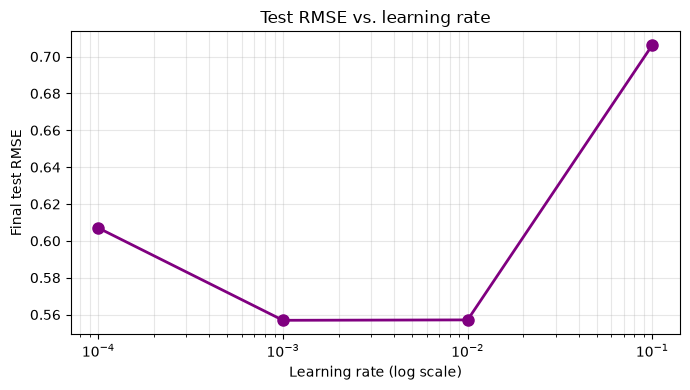

In [8]:
### YOUR CODE HERE

learning_rates = [1e-1, 1e-2, 1e-3, 1e-4]
final_test_rmse = []

for lr in learning_rates:
    torch.manual_seed(42)
    m = RegressorFFN()
    opt = optim.Adam(m.parameters(), lr=lr)
    trainModel(m, n_epochs=100, optimizer=opt, loss_fn=nn.MSELoss(),
               data_loader=train_loader)
    rmse = evaluate(m, x_test_t, y_test_t)[0]
    final_test_rmse.append(rmse)
    print(f"lr={lr:<7}  ->  test RMSE = {rmse:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(learning_rates, final_test_rmse, "o-", color="purple", linewidth=2, markersize=8)
plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Final test RMSE")
plt.title("Test RMSE vs. learning rate")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

**Interpretation.** There is a sweet spot in the middle (around `1e-2` to `1e-3`).

- **Too high (`1e-1`):** each update overshoots the minimum; the loss oscillates or diverges and the final test RMSE is high — training is unstable.
- **Too low (`1e-4`):** updates are tiny, so in a fixed 100 epochs the model barely moves and **underfits** — it hasn't converged yet, so test RMSE is also high.

The U-shaped curve is the classic learning-rate trade-off: fast enough to make progress, but not so fast that it overshoots.